In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

In [2]:
smartcart = pd.read_csv("smartcart_customers.csv")

# Data Preprocessing

# 1. Handle missing values


In [3]:
smartcart["Income"] = smartcart["Income"].fillna(smartcart["Income"].median())

In [4]:
smartcart.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


# 2. Feature Engineering

In [5]:
# Converting year_birth into age
smartcart["Age"] = 2026-smartcart["Year_Birth"]

In [6]:
#Converting dt_customer into customerTenure 
smartcart["Dt_Customer"] = pd.to_datetime(smartcart["Dt_Customer"],dayfirst=True)
reference_date = smartcart["Dt_Customer"].max()

smartcart["Customer_Tenure_Days"] = (reference_date - smartcart["Dt_Customer"]).dt.days #total no of days

In [7]:
#spending (merge)
smartcart["TotalSpending"] = smartcart[["MntWines","MntFishProducts","MntSweetProducts","MntGoldProds","MntFruits","MntMeatProducts"]].sum(axis = 1)

In [8]:
#children
smartcart["TotalChildren"] = smartcart[["Kidhome","Teenhome"]].sum(axis = 1)

In [9]:
#Education
#Turning into categories
smartcart["Education"]= smartcart["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "Master": "Postgraduate",
    "PhD": "Postgraduate"
})

smartcart["Education"].value_counts()



Education
Graduate         1127
Postgraduate      856
Undergraduate     257
Name: count, dtype: int64

In [10]:
#Maritial status
smartcart["Living_With"]= smartcart["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced": "Alone",
    "Widow": "Alone",
    "Absurd":"Alone",
    "YOLO":"Alone"
})

smartcart["Living_With"].value_counts()

Living_With
Partner    1444
Alone       796
Name: count, dtype: int64

# 3. Drop Column

In [11]:
smartcart.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'TotalSpending',
       'TotalChildren', 'Living_With'],
      dtype='str')

In [12]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]
cols_to_drop = cols + spending_cols
smartcart_cleaned = smartcart.drop(cols_to_drop,axis=1)

In [13]:
smartcart_cleaned.shape

(2240, 15)

# 4 .Handling Outliers

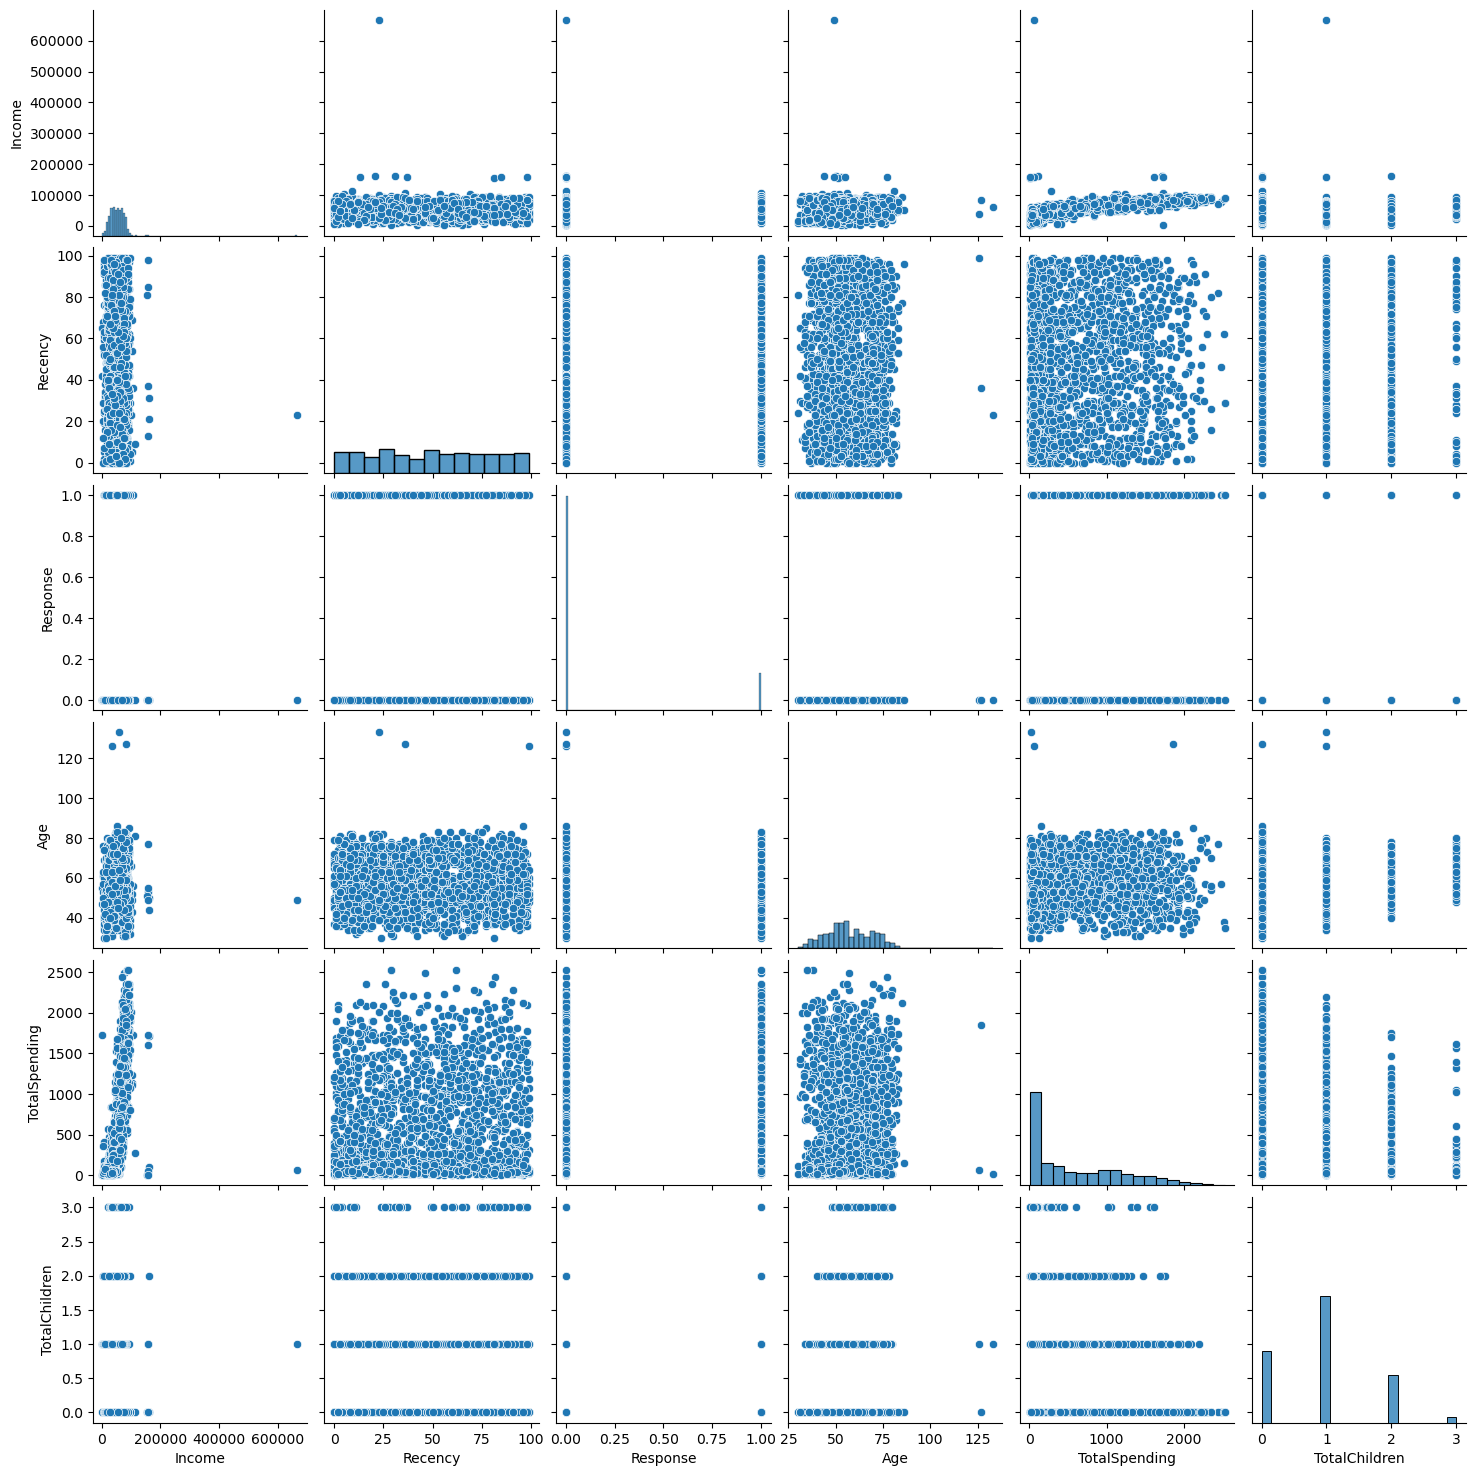

In [14]:
cols = ["Income","Recency","Response","Age","TotalSpending","TotalChildren"]

#relative plots of some features - pair plots
sns.pairplot(smartcart_cleaned[cols])

In [15]:
#Remove Outlier
print("Data size with outliers:",len(smartcart_cleaned))
smartcart_cleaned = smartcart_cleaned[(smartcart_cleaned["Age"]< 90)]
smartcart_cleaned = smartcart_cleaned[(smartcart_cleaned["Income"]< 600000)]

print("Data size without outliers:",len(smartcart_cleaned))

Data size with outliers: 2240
Data size without outliers: 2236


# 5. Heatmap

<Axes: >

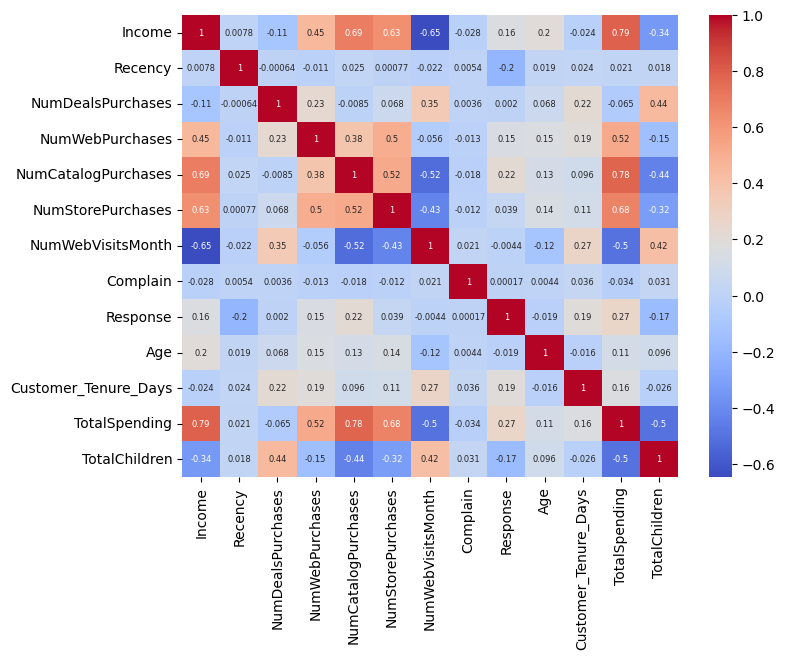

In [16]:
corr = smartcart_cleaned.corr(numeric_only = True)
plt.figure(figsize=(8,6))
sns.heatmap(
    corr,
    annot = True,
    annot_kws={"size":6},
    cmap = "coolwarm"
)

# 6. Feature encoding and scaling

In [17]:
from sklearn.preprocessing import OneHotEncoder

In [18]:
ohe = OneHotEncoder()
cat_cols = ["Education","Living_With"]
#using one hot encoding and changing it to df
enc_cols = ohe.fit_transform(smartcart_cleaned[cat_cols])
enc_smartcart = pd.DataFrame(enc_cols.toarray(),columns=ohe.get_feature_names_out(cat_cols),index = smartcart_cleaned.index)

In [19]:
#concatinating df into out cleaned dataset
smartcart_encoded = pd.concat([smartcart_cleaned.drop(columns = cat_cols),enc_smartcart],axis = 1)

In [20]:
smartcart_encoded.head()

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,TotalSpending,TotalChildren,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,0.0,1.0,0.0,0.0,1.0


In [21]:
X = smartcart_encoded

In [22]:
#Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [23]:
X_scaled

array([[ 0.28894655,  0.30685572,  0.34873831, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [-0.262003  , -0.38397129, -0.16869955, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.91842301, -0.7984675 , -0.68613742, ..., -0.35877969,
        -0.74204052,  0.74204052],
       ...,
       [ 0.234898  ,  1.44672029, -0.68613742, ..., -0.35877969,
         1.3476353 , -1.3476353 ],
       [ 0.80780332, -1.42021181, -0.16869955, ..., -0.35877969,
        -0.74204052,  0.74204052],
       [ 0.04280841, -0.31488859,  0.34873831, ..., -0.35877969,
        -0.74204052,  0.74204052]], shape=(2236, 18))

## Visualization

In [24]:
from sklearn.decomposition import PCA

#2D visualization
# pca = PCA(n_components = 2)
# X_pca = pca.fit_transform(X_scaled)

# #plot
# plt.scatter(X_pca[:,0],X_pca[:,1])
# pca.explained_variance_ratio_

Text(0.5, 0.92, '3d projection')

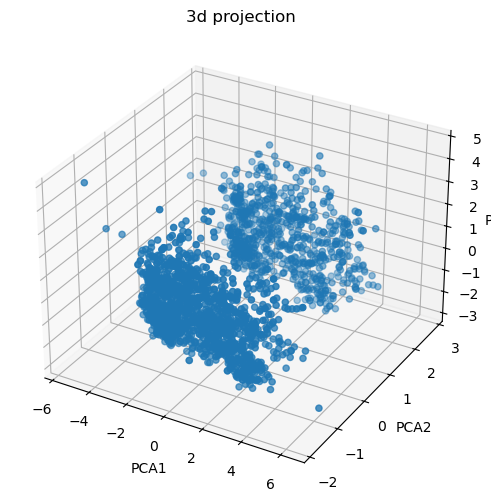

In [25]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)


fig = plt.figure(figsize= (8,6))
ax = fig.add_subplot(111,projection = "3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2])

ax.set_xlabel("PCA1")
ax.set_ylabel("PCA2")
ax.set_zlabel("PCA3")
ax.set_title("3d projection")

# Model Building

## Analyze k value 
### 1. Elbow method

In [26]:
from sklearn.cluster import KMeans
from kneed import KneeLocator
wcss = []
for k in range(1,11):
    kmeans = KMeans(n_clusters=k,random_state = 42)
    kmeans.fit_predict(X_pca)
    wcss.append(kmeans.inertia_)

In [27]:
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")
optimal_k = knee.elbow

In [28]:
print("best k:",optimal_k)

best k: 4


Text(0, 0.5, 'Wcss')

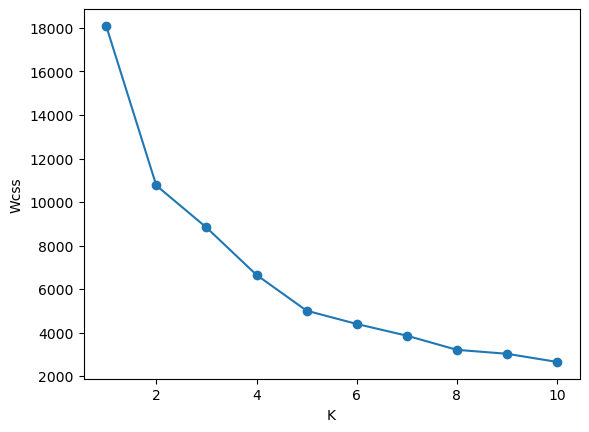

In [29]:
#plot
plt.plot(range(1,11),wcss,marker="o")
plt.xlabel("K")
plt.ylabel("Wcss")

## 2. Silhouette Score

Text(0, 0.5, 'silouette Scores')

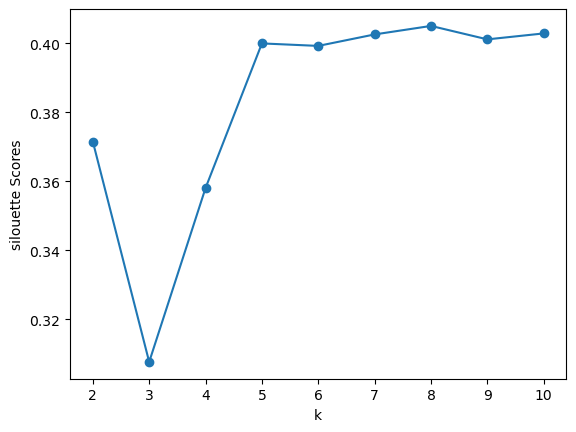

In [30]:
from sklearn.metrics import silhouette_score
scores =[]
for k in range(2,11):
    kmeans = KMeans(n_clusters=k,random_state=42)
    labels = kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

#plot
plt.plot(range(2,11),scores,marker="o")
plt.xlabel("k")
plt.ylabel("silouette Scores")

Text(0, 0.5, 'Silhouette score')

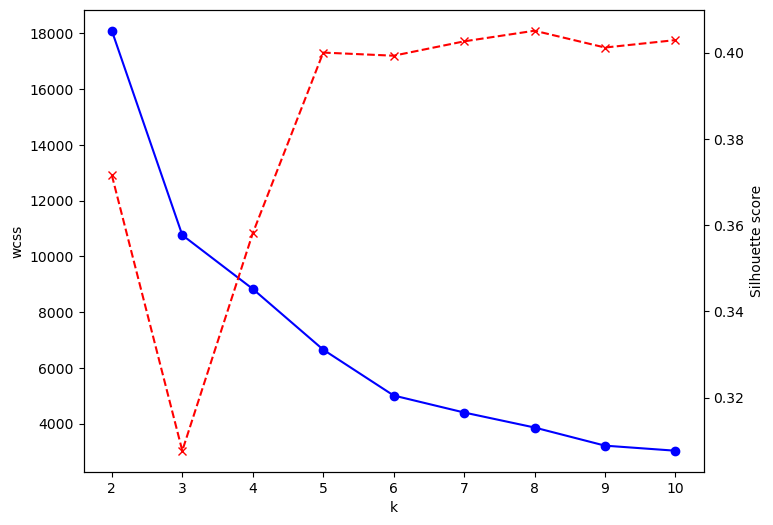

In [31]:
# combined plot
k_range = range(2,11)
fig,ax1 = plt.subplots(figsize=(8,6))
ax1.plot(k_range,wcss[:len(k_range)],marker="o",color="blue")
ax1.set_xlabel("k")
ax1.set_ylabel("wcss")

ax2=ax1.twinx()
ax2.plot(k_range,scores[:len(k_range)],marker="x",color="red",linestyle="--")
ax2.set_ylabel("Silhouette score")

# Clustering

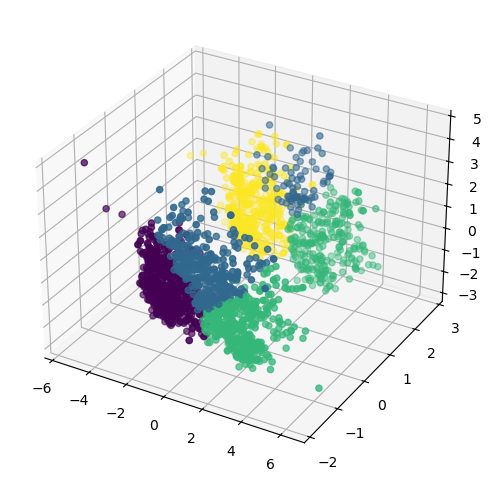

In [32]:
#k-means
kmeans= KMeans(n_clusters=4,random_state=42)
labels_kmeans = kmeans.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax=fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_kmeans)

In [33]:
#Agglomerative clustering
from sklearn.cluster import AgglomerativeClustering

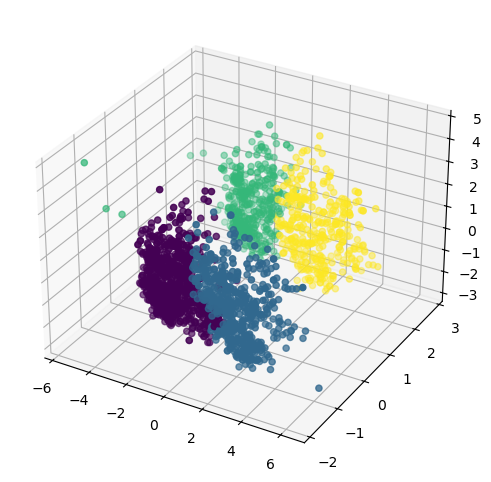

In [34]:
agg_clf = AgglomerativeClustering(n_clusters=4,linkage="ward")
labels_agg = agg_clf.fit_predict(X_pca)

fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111,projection="3d")
ax.scatter(X_pca[:,0],X_pca[:,1],X_pca[:,2],c=labels_agg)

# characterization of Clusters

In [35]:
smartcart_cleaned["cluster"] = labels_agg

In [36]:
smartcart_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,TotalSpending,TotalChildren,Living_With,cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0


<Axes: xlabel='cluster', ylabel='count'>

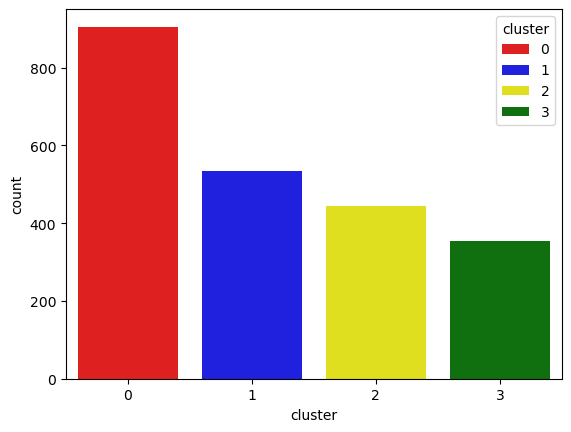

In [38]:
pal = ["red","blue","yellow","green"]
sns.countplot(x=smartcart_cleaned["cluster"],palette=pal,hue=smartcart_cleaned["cluster"])

<Axes: xlabel='TotalSpending', ylabel='Income'>

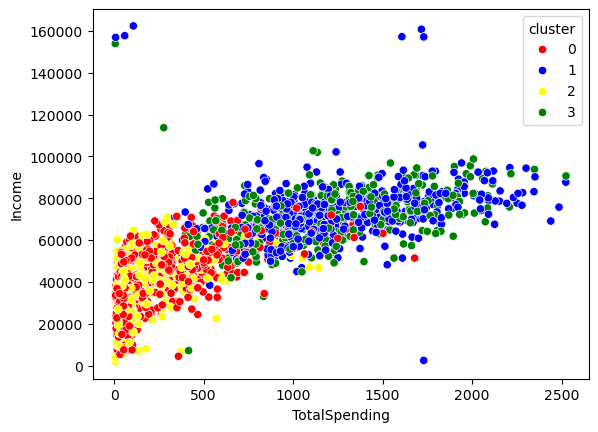

In [42]:
# Income and spending pattern checking
sns.scatterplot(x=smartcart_cleaned["TotalSpending"],y=smartcart_cleaned["Income"],hue=smartcart_cleaned["cluster"],palette=pal)